# Assignment 4: Regularization

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?
2. How does regularization provide a way of exploring the bias-variance trade-off?
3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?
4. How do we typically scale variables for use in regularized regression? Why?
5. How is the penalty $\alpha$ typically selected?
6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them.
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?
7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

In [1]:
! git clone https://github.com/SafaaMahbub/undergrad_ml_assignments
%run ./undergrad_ml_assignments/get_data.py

Cloning into 'undergrad_ml_assignments'...
remote: Enumerating objects: 265, done.
remote: Counting objects: 100% (4/4), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 265 (delta 1), reused 0 (delta 0), pack-reused 261 (from 2)
Receiving objects: 100% (265/265), 17.04 MiB | 16.69 MiB/s, done.
Resolving deltas: 100% (122/122), done.
Download complete
Extracting data files...
Data extracted


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn as sns
from sklearn.linear_model import LassoCV, lasso_path, LinearRegression, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
poly = PolynomialFeatures(degree=2, include_bias=False)
df = pd.read_csv('./data/cars_hw.csv')
df.head()

df["Age"] = 2026 - df["Make_Year"]
feature = df[["Mileage_Run","Age"]]
poly = PolynomialFeatures(degree=3, include_bias=False)

X_poly = poly.fit_transform(feature)
poly_names = poly.get_feature_names_out(["Mileage_Run","Age"])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)
y = df["Price"]

linear_model = LinearRegression()
linear_model.fit(X_scaled, y)
coeffs_lin = pd.Series(linear_model.coef_, index=poly_names)

interaction = "Mileage_Run Age"

print(f"observations of the interactions {interaction}: {'Postive' if coeffs_lin[interaction]>0 else 'Negative'}")




observations of the interactions Mileage_Run Age: Negative


mileage worsenes as age increases

In [18]:
alphas = np.logspace(1,3,20)
model = LassoCV(cv=20, alphas=alphas, random_state=100, max_iter=100000)
model = model.fit(X_scaled, y)

index_star = np.argmin( np.median(model.mse_path_,axis=1) )
alpha_star = model.alphas_[index_star]

Optimal cost hyperparameter: 1000.0


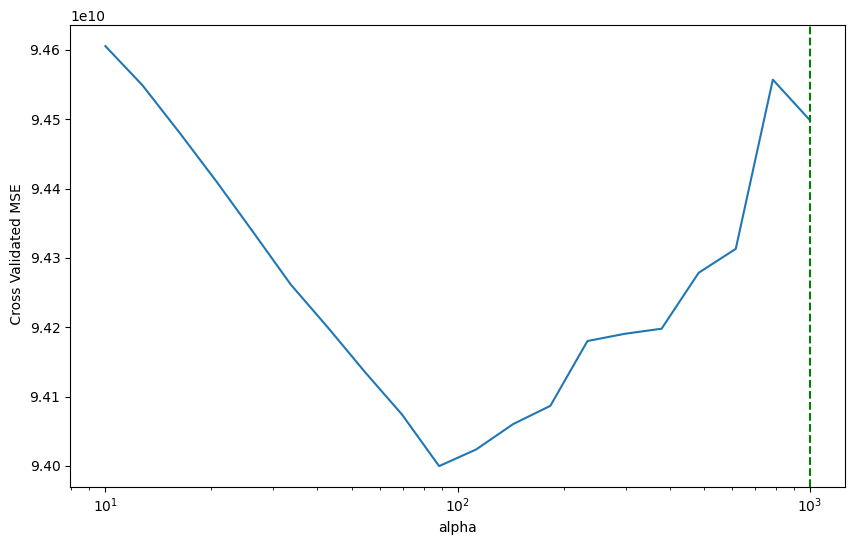

Optimal cost hyperparameter: 1000.0


In [20]:
plt.figure(figsize=(10,6))
sns.lineplot( x=model.alphas_, y= np.mean(model.mse_path_,axis=1) )
plt.axvline(x=alpha_star, color='green', linestyle='--',
            linewidth=1.5)
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel(" Cross Validated MSE")
print(f'Optimal cost hyperparameter: {alpha_star}')

plt.show()
print(f"Optimal cost hyperparameter: {alpha_star}")

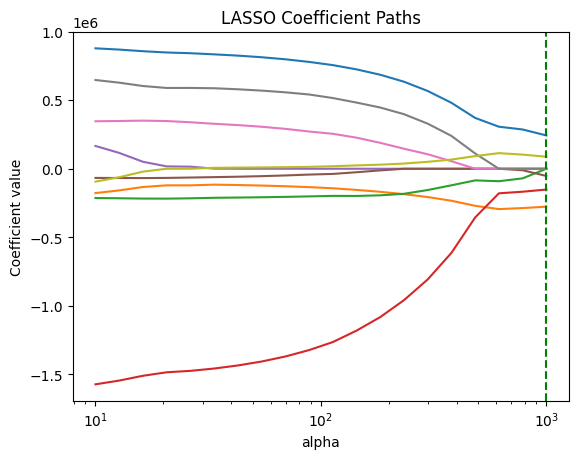

In [24]:
coefs = []
for alpha in alphas: # For each alpha value,
    model = Lasso(alpha=alpha, max_iter=100000) # Create a lasso model
    model = model.fit(X_scaled,y) # Run the regression
    coefs.append(model.coef_) # Save the slope coefficients
coefs = np.array(coefs) # Cast list of lists to array

plt.figure()
for i in range(coefs.shape[1]):
    plt.plot(alphas, coefs[:, i], label=poly_names[i]) # Switched in poly_names
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Coefficient value")
plt.title("LASSO Coefficient Paths")
plt.axvline(x=alpha_star, color='green', linestyle='--')
plt.show()

In [26]:
coefficients = model.coef_
selected_features = poly_names[model.coef_ != 0]
print(f"Selected Features: {selected_features}")

Selected Features: ['Mileage_Run' 'Age' 'Mileage_Run Age' 'Mileage_Run^3' 'Age^3']


In [27]:
zero_count = np.sum(coefficients == 0)
proportion_zero = zero_count / len(coefficients)

print("--- Selected Features ---")
print(selected_features)
print(f"\nProportion of features set to zero: {proportion_zero:.2%}")

--- Selected Features ---
['Mileage_Run' 'Age' 'Mileage_Run Age' 'Mileage_Run^3' 'Age^3']

Proportion of features set to zero: 44.44%


In [28]:
coeffs_lasso = pd.Series(model.coef_, index=poly_names)
coeffs_lin = pd.Series(linear_model.coef_, index=poly_names)
comparison = pd.DataFrame({"Linear": coeffs_lin, "Lasso": coeffs_lasso})

comparison["increase"] = comparison["Lasso"].abs() > comparison["Linear"].abs()
comparison["sign_change"] = comparison["Lasso"] * comparison["Linear"] < 0
print(comparison)



                         Linear          Lasso  increase  sign_change
Mileage_Run        9.117748e+05  242953.216388     False        False
Age               -2.481722e+05 -276500.895776      True        False
Mileage_Run^2     -2.072926e+05      -0.000000     False        False
Mileage_Run Age   -1.671212e+06 -151598.545767     False        False
Age^2              3.505507e+05      -0.000000     False        False
Mileage_Run^3     -6.514490e+04  -52410.347536     False        False
Mileage_Run^2 Age  3.388195e+05      -0.000000     False        False
Mileage_Run Age^2  7.167816e+05      -0.000000     False        False
Age^3             -2.100379e+05   87796.740706     False         True


**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn as sns
from sklearn.linear_model import LassoCV, lasso_path, LinearRegression, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
poly = PolynomialFeatures(degree=2, include_bias=False)
df = pd.read_csv('./data/heart_failure_clinical_records_dataset.csv')
df.head()

features = df[['age', 'ejection_fraction', 'serum_creatinine']]
poly = PolynomialFeatures(degree=3, include_bias=False)

X_poly = poly.fit_transform(feature)
poly_names = poly.get_feature_names_out(['age', 'ejection_fraction', 'serum_creatinine'])
y = df["DEATH_EVENT"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

cat_variables = df[['anaemia', 'diabetes', 'high_blood_pressure', 'smoking']]
cat_poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)

X_cat_interact = cat_poly.fit_transform(df[cat_variables])
cat_names = cat_poly.get_feature_names_out(cat_variables)

# --- Part C: Combine ---
X_final = np.hstack([X_scaled, X_cat_interact])
all_feature_names = np.concatenate([poly_names, cat_names])



ValueError: input_features is not equal to feature_names_in_

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?
2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.
3. How does increasing $\alpha$ change the slope coefficient?
4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?